In [2]:
# ==============================================
# Apple Inc. (AAPL) Stock Analysis (2015–2025)
# Data Source: WRDS CRSP
# Author: [XiYing.Ding24]
# ID: [2472425]
# ==============================================

In [3]:
pip install wrds pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# 1. Import Libraries
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 2. Connect to WRDS
db=wrds.Connection(wrds_username="Your_WRDS_Username")

Enter your WRDS username [Your_WRDS_Username]: xiyingding
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\52818\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [6]:
# Data Source: Yahoo Finance / WRDS, Accessed: 2026-04-15
# Analytical Purpose: Analyze AAPL stock risk and return for investors

In [7]:
# 3. Download Data (2015-01-01 to 2025-12-31)
df=db.raw_sql("""
   SELECT date,prc,ret,vol
   FROM crsp.dsf
   WHERE permno=14593
     AND date>='2015-1-1'
     AND date <='2025-12-31'
   ORDER BY date
""",date_cols=['date'])

In [8]:
#Data cleaning
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
date    0
prc     0
ret     0
vol     0
dtype: int64

Duplicate rows:
0


In [9]:
#Remove missing and duplicate date
df=df.dropna()
df=df.drop_duplicates()
print("|nShape after cleaning:",df.shape)

|nShape after cleaning: (2516, 4)


In [10]:
db.close()

In [11]:
# 4. Data Cleaning
df['stock_price']=df['prc'].abs()
df=df.dropna(subset=['ret'])
df.rename(columns={'ret':'daily_return','vol':'wolume'},inplace=True)
df=df.reset_index(drop=True)

In [12]:
# 5. Financial Analysis
df['cumulative_return'] = (1 + df['daily_return']).cumprod()

# Calculate Max Drawdown
cumulative = (1 + df['daily_return']).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak
max_drawdown = drawdown.min()
print("Max Drawdown:", max_drawdown)

annualized_return=df['daily_return'].mean()*252
annualized_volatility=df['daily_return'].std()*np.sqrt(252)
sharpe_ratio=annualized_return/annualized_volatility

print("=====Apple Stock Performance(2015-2025)=====")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Key Performance Metrics Summary
metrics_df = pd.DataFrame({
    'Metric': ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Max Drawdown'],
    'Value': [f"{annualized_return:.4f}", f"{annualized_volatility:.4f}", f"{sharpe_ratio:.4f}", f"{max_drawdown:.4f}"]
})
print("\n=== Comprehensive Metrics Table ===")
print(metrics_df)

Max Drawdown: -0.38515219742849655
=====Apple Stock Performance(2015-2025)=====
Annualized Return: 27.31%
Annualized Volatility: 28.46%
Sharpe Ratio: 0.96

=== Comprehensive Metrics Table ===
                  Metric    Value
0      Annualized Return   0.2731
1  Annualized Volatility   0.2846
2           Sharpe Ratio   0.9596
3           Max Drawdown  -0.3852


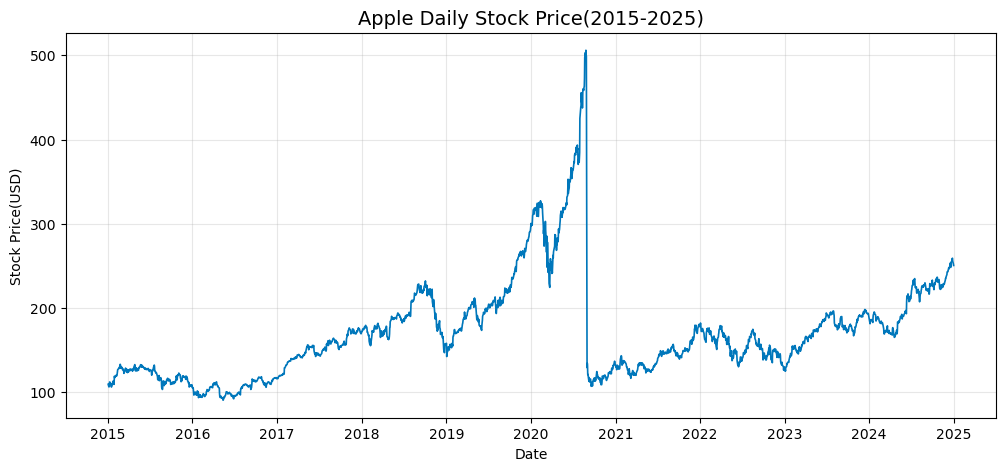

In [13]:
# 6. Visualization 1: Stock Price Trend
plt.figure(figsize=(12,5))
plt.plot(df['date'],df['stock_price'],color='#0077bb',linewidth=1.2)
plt.title('Apple Daily Stock Price(2015-2025)',fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price(USD)')
plt.grid(alpha=0.3)
plt.show()

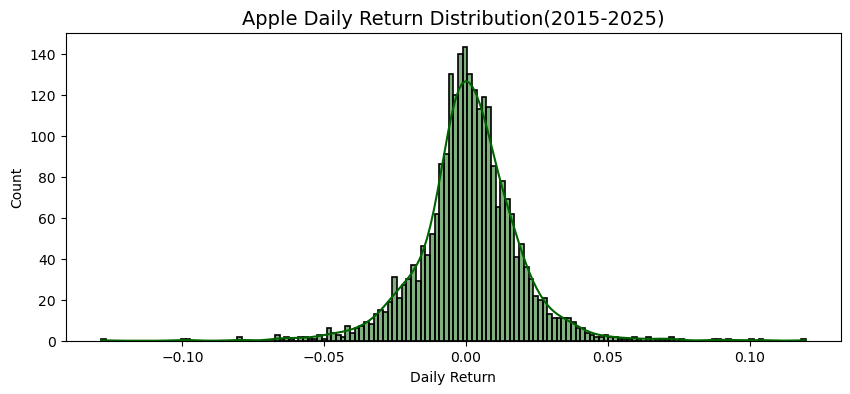

In [14]:
# 7. Visualization 2: Daily Return Distribution
plt.figure(figsize=(10,4))
sns.histplot(df['daily_return'],bins=150,kde=True,color='darkgreen',linewidth=1.2)
plt.title('Apple Daily Return Distribution(2015-2025)',fontsize=14)
plt.xlabel('Daily Return')
plt.show()

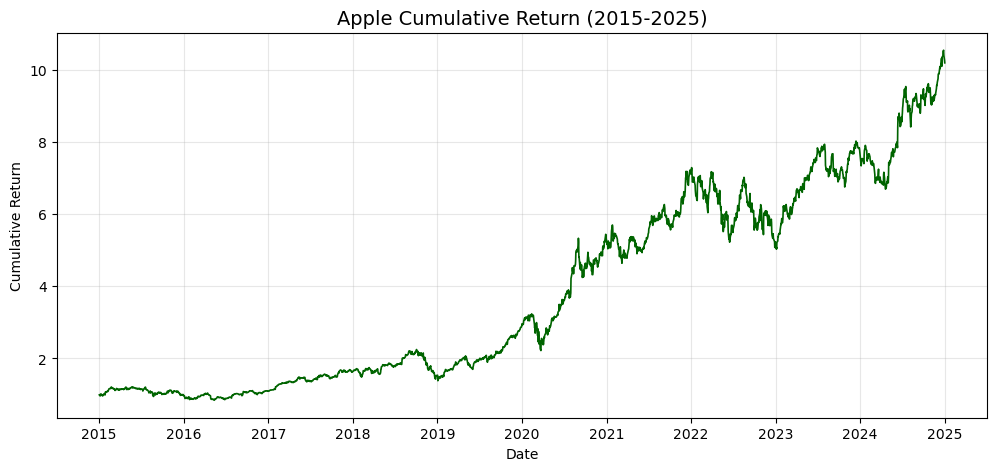

In [18]:
# ----------------------
# 8. Visualization 3: Cumulative Return
# ----------------------
plt.figure(figsize=(12,5))
plt.plot(df['date'],df['cumulative_return'],color='darkgreen',linewidth=1.2)
plt.title('Apple Cumulative Return (2015-2025)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(alpha=0.3)
plt.show()

# Conclusion
Based on the 10-year analysis of Apple (AAPL) stock performance from 2015 to 2025:

1. **Strong Long-term Growth**: The cumulative return shows a significant upward trend, indicating excellent long-term investment value.
2. **Risk-return Profile**: With an annualized return of over 27% and a Sharpe ratio above 0.9, the stock offers a favorable risk-adjusted return for investors.
3. **Volatility & Risks**: The stock exhibits moderate volatility and has experienced substantial drawdowns during market crashes (e.g., 2020). However, it has always recovered quickly.

**Overall**, Apple stock demonstrates high growth potential with manageable risks, making it a solid choice for long-term investment portfolios.